# Fit LG — Google+ ego networks (`gplus`)

Batch fit and model comparison for **all networks** in this collection.

All Google+ ego nets with |V| ≥ 100 (`data/misc/gplus/*.edges`), sorted by |V|.

**Per network**, the fit loop logs four steps and saves a 4-panel report (`runs/gplus/{graph}/fit_report.png`):

1. **Load** — graph size and structural attributes  
2. **AIC** — pick `d̂` over candidates `[0,1,2,3]`  
3. **σ̂** — Layer-2 offset logit at `d̂`  
4. **Compare** — LG vs ER / WS / BA (`GraphModelComparator`, spectral GIC)

Aggregate tables and plots land in `runs/gplus/`. Full log: `runs/gplus/platform.log`.

## 1. Discover networks

In [1]:
import os
import sys
import warnings
from pathlib import Path

for v in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(v, "1")
warnings.filterwarnings("ignore", category=DeprecationWarning)

_REFACTOR = Path.cwd()
if str(_REFACTOR) not in sys.path:
    sys.path.insert(0, str(_REFACTOR))

from platform_fit_utils import PlatformConfig, discover_graph_files, print_discovery

# ---- Batch settings (edit here) --------------------------------------------
MIN_NODES = 50
MAX_NODES = 500      # skip graphs with n > MAX_NODES; set None for no cap
USE_CACHE = True     # reload finished networks from runs/{platform}/{graph}/

cfg = PlatformConfig(
    platform="gplus",
    glob_pattern="misc/gplus/*.edges",
    min_nodes=MIN_NODES,
    max_nodes=MAX_NODES,
    use_cache=USE_CACHE,
    display_plots=False,
)

graph_files = discover_graph_files(cfg)
print_discovery(cfg, graph_files)

Skipped 1 unreadable/empty graphs
  111278293763545982455.edges: Empty graph loaded from ../../data/misc/gplus/111278293763545982455.edges
Skipped 92 graphs with n > 500 (MAX_NODES)
  100129275726588145876.edges: n=1648
  100329698645326486178.edges: n=2211
  100500197140377336562.edges: n=638
  100521671383026672718.edges: n=521
  100535338638690515335.edges: n=1187
  ... and 87 more
PLATFORM=gplus  RUN_DIR=/Users/maruanottoni/home/master/research/all_logit/logit-graph/notebooks/refactors/runs/gplus
Found 34 networks (MIN_NODES=50, MAX_NODES=500, USE_CACHE=True)
     110739220927723360152.edges  n=   54  |E|=    203
     110241952466097562819.edges  n=   83  |E|=    671
     116450966137824114154.edges  n=   92  |E|=    837
     101848191156408080085.edges  n=   94  |E|=   1005
     110809308822849680310.edges  n=   97  |E|=    464
     102615863344410467759.edges  n=  102  |E|=   1169  [cached]
     113455290791279442483.edges  n=  108  |E|=   2352  [cached]
     11023247981813635568

## 2. Fit all networks

In [2]:
from platform_fit_utils import fit_all_networks

comparators, summary_all, fit_meta, failures = fit_all_networks(graph_files, cfg)
RUN_DIR = cfg.run_dir

18:59:57  === gplus batch fit  (34 networks, MAX_NODES=500, cache=True) ===
18:59:57  [1/34] 110739220927723360152
18:59:57    STEP 1/4  Load graph  n=54 |E|=203 density=0.1419 clustering=0.498 assort=0.074
18:59:57    STEP 2/4  AIC select d  d̂=1  (d=0:AIC=1170.6  d=1:AIC=948.1  d=2:AIC=1081.0  d=3:AIC=1326.7)  [0.2s]
18:59:57    STEP 3/4  Estimate σ at d̂  σ̂=-2.7379  [0.0s]
18:59:57    STEP 4/4  Model comparison  LG max_iter=4000  baselines=ER/WS/BA

============================== Processing Graph: 110739220927723360152 ==============================

--- Fitting Logit Graph (LG) model ---
Running LG generation for d=1 (warm_start_p=0.0608)...


Optimizing Graph:   0%|          | 0/4000 [00:00<?, ?it/s] 

GIC threshold 5 reached at iteration 0 (GIC: 3.0536). Starting spectrum patience (500 checks).

Stopping: max iterations (4,000) reached
  Best iteration: 3,600
  Best spectrum diff: 29.8245
  Edges in best graph: 138 (real: 203)
d=1: GIC=6.8845, sigma=-2.7379
Best LG fit found with GIC: 6.8845

--- Fitting other random graph models ---
Testing the selected model for ER
ER gic: 9.747294123957332
Testing the selected model for WS
WS gic: 10.907233867312332
Testing the selected model for BA
BA gic: 8.901341271427945
BA fitting - GIC: 8.9013, Param: 6.2500
ER fitting - GIC: 9.7473, Param: 0.2500
WS fitting - GIC: 10.9072, Param: 80.2550

--- Calculating graph attributes ---
18:59:58    RESULT  best=LG  GIC=6.884  (LG=6.884  BA=8.901  ER=9.747  WS=10.907)  [compare 0.3s | total 0.6s]
18:59:58    Saved fit_report.png
18:59:58  [2/34] 110241952466097562819
18:59:58    STEP 1/4  Load graph  n=83 |E|=671 density=0.1972 clustering=0.702 assort=-0.512
18:59:58    STEP 2/4  AIC select d  d̂=1  (d

Optimizing Graph:   0%|          | 0/4000 [00:00<?, ?it/s] 

GIC threshold 5 reached at iteration 0 (GIC: 1.0688). Starting spectrum patience (500 checks).

Stopping: max iterations (4,000) reached
  Best iteration: 2,450
  Best spectrum diff: 157.7338
  Edges in best graph: 183 (real: 671)
d=1: GIC=4.5981, sigma=-3.0973
Best LG fit found with GIC: 4.5981

--- Fitting other random graph models ---
Testing the selected model for ER
ER gic: 3.877965773780782
Testing the selected model for WS
WS gic: 5.352780345206909
Testing the selected model for BA
BA gic: 4.125018691746433
ER fitting - GIC: 3.8780, Param: 0.2500
BA fitting - GIC: 4.1250, Param: 8.0000
WS fitting - GIC: 5.3528, Param: 80.1325

--- Calculating graph attributes ---
18:59:58    RESULT  best=ER  GIC=3.878  (ER=3.878  BA=4.125  LG=4.598  WS=5.353)  [compare 0.3s | total 0.4s]
18:59:58    Saved fit_report.png
18:59:58  [3/34] 116450966137824114154
18:59:58    STEP 1/4  Load graph  n=92 |E|=837 density=0.2000 clustering=0.633 assort=-0.356
18:59:58    STEP 2/4  AIC select d  d̂=1  (d=0

...

GIC threshold 5 reached at iteration 0 (GIC: 0.9165). Starting spectrum patience (500 checks).

Stopping: max iterations (4,000) reached
  Best iteration: 3,900
  Best spectrum diff: 180.5122
  Edges in best graph: 234 (real: 837)
d=1: GIC=4.1349, sigma=-3.0806
Best LG fit found with GIC: 4.1349

--- Fitting other random graph models ---
Testing the selected model for ER
ER gic: 4.9784751414985555
Testing the selected model for WS
WS gic: 5.112998269437802
Testing the selected model for BA
BA gic: 2.881379284693488
BA fitting - GIC: 2.8814, Param: 8.0000
ER fitting - GIC: 4.9785, Param: 0.2500
WS fitting - GIC: 5.1130, Param: 80.1325

--- Calculating graph attributes ---
18:59:59    RESULT  best=BA  GIC=2.881  (BA=2.881  LG=4.135  ER=4.978  WS=5.113)  [compare 0.4s | total 0.5s]
18:59:59    Saved fit_report.png
18:59:59  [4/34] 101848191156408080085
18:59:59    STEP 1/4  Load graph  n=94 |E|=1005 density=0.2299 clustering=0.611 assort=-0.247
18:59:59    STEP 2/4  AIC select d  d̂=1  (d

Optimizing Graph:   0%|          | 0/4000 [00:00<?, ?it/s] 

GIC threshold 5 reached at iteration 0 (GIC: 0.8107). Starting spectrum patience (500 checks).

Stopping: max iterations (4,000) reached
  Best iteration: 3,950
  Best spectrum diff: 187.3813
  Edges in best graph: 352 (real: 1005)
d=1: GIC=3.0397, sigma=-2.8554
Best LG fit found with GIC: 3.0397

--- Fitting other random graph models ---
Testing the selected model for ER
ER gic: 3.8949254152306687
Testing the selected model for WS
WS gic: 5.562940047193523
Testing the selected model for BA
BA gic: 3.243977189116559
BA fitting - GIC: 3.2440, Param: 8.0000
ER fitting - GIC: 3.8949, Param: 0.2500
WS fitting - GIC: 5.5629, Param: 80.1325

--- Calculating graph attributes ---
19:00:00    RESULT  best=LG  GIC=3.040  (LG=3.040  BA=3.244  ER=3.895  WS=5.563)  [compare 0.6s | total 0.7s]
19:00:00    Saved fit_report.png
19:00:00  [5/34] 110809308822849680310
19:00:00    STEP 1/4  Load graph  n=97 |E|=464 density=0.0997 clustering=0.298 assort=-0.170
19:00:00    STEP 2/4  AIC select d  d̂=1  (d

Optimizing Graph:   0%|          | 0/4000 [00:00<?, ?it/s] 

GIC threshold 5 reached at iteration 0 (GIC: 1.0082). Starting spectrum patience (500 checks).

Stopping: max iterations (4,000) reached
  Best iteration: 3,650
  Best spectrum diff: 89.1364
  Edges in best graph: 175 (real: 464)
d=1: GIC=2.9821, sigma=-3.2441
Best LG fit found with GIC: 2.9821

--- Fitting other random graph models ---
Testing the selected model for ER
ER gic: 6.502585858983556
Testing the selected model for WS
WS gic: 5.130331088680975
Testing the selected model for BA
BA gic: 7.329858335131959
WS fitting - GIC: 5.1303, Param: 80.3775
ER fitting - GIC: 6.5026, Param: 0.1300
BA fitting - GIC: 7.3299, Param: 8.0000

--- Calculating graph attributes ---
19:00:00    RESULT  best=LG  GIC=2.982  (LG=2.982  WS=5.130  ER=6.503  BA=7.330)  [compare 0.4s | total 0.5s]
19:00:01    Saved fit_report.png
19:00:01  [6/34] 102615863344410467759  CACHED  (n=102, best=BA, GIC=2.948)
19:00:01  [7/34] 113455290791279442483  CACHED  (n=108, best=BA, GIC=3.236)
19:00:01  [8/34] 1102324798

## 3. Aggregate comparison

In [3]:
from platform_fit_utils import summarize_aggregates

gic_pivot, rank_pivot, mean_rank = summarize_aggregates(summary_all, RUN_DIR)

Mean GIC rank by model (lower = better):
model
LG    1.412
BA    2.353
ER    3.059
WS    3.176
dtype: float64

model                     LG      ER      WS      BA
graph_filename                                      
100466178325794757407  3.488   5.820   4.868   4.641
100518419853963396365  3.332   6.849   5.213   3.395
100637660947564674695  3.541   9.986   5.462   4.104
101499880233887429402  3.885   5.609   5.287  26.881
101541879642294398860  3.301   6.444   5.257   3.218
102615863344410467759  3.487   3.856   4.810   2.948
103241736833663734962  3.342   7.184   4.815   4.244
103251633033550231172  3.608   7.265   4.908   3.645
103503116383846951534  3.421   8.349   4.674   3.952
104105354262797387583  4.623   4.421   5.680  23.145
104672614700283598130  3.576   4.381   5.564   3.673
107965826228461029730  3.609   6.476   5.370   3.351
108404515213153345305  3.646   7.877   5.243  25.139
110232479818136355682  2.995   5.306   5.181   4.409
110614416163543421878  3.759   4.536   5.

## 4. Summary plots

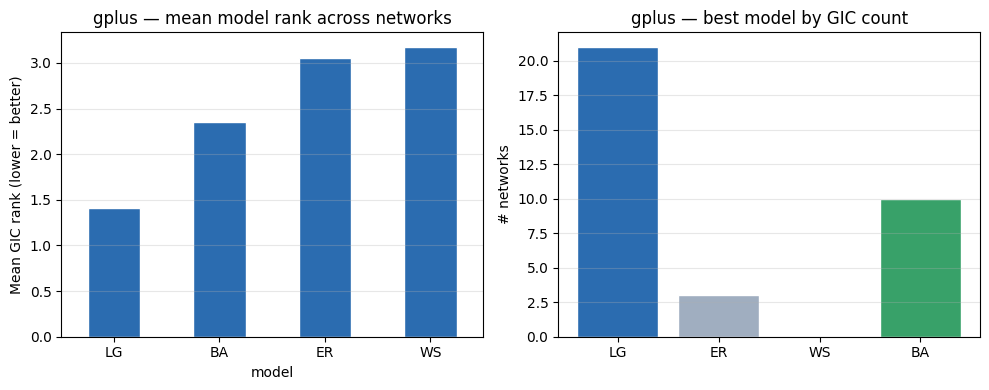

Saved runs/gplus/aggregate_model_comparison.png


PosixPath('runs/gplus/aggregate_model_comparison.png')

In [4]:
from platform_fit_utils import plot_aggregate_summary

plot_aggregate_summary(fit_meta, mean_rank, RUN_DIR, cfg.platform, display=True)